In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv(
    "../data/raw/Student_Feedback.csv",
    encoding="latin-1"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [12]:
print("Dataset Shape:", df.shape)
display(df.head(10))
df.info()
print("Columns:")
print(df.columns.tolist())

print("Missing values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Dataset Shape: (1086, 2)


,comments,sentiments
0,TEACHERS HELP US IN CAREER BUILDING,1
1,Having no technical knowledge about their taug...,0
2,teacher should give us the practical knowledge...,2
3,better teaching methodology,1
4,best teaching method,1
5,teaching method is very tough and very diffcul...,0
6,THEY IMPART modern and latest knowledge to us,1
7,teachers give us all the required information ...,1
8,Your teaching style is engaging,1
9,least EXPOSURE to modern trends discussed,0


<class 'pandas.DataFrame'>
RangeIndex: 1086 entries, 0 to 1085
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   comments    1086 non-null   str  
 1   sentiments  1086 non-null   int64
dtypes: int64(1), str(1)
memory usage: 17.1 KB
Columns:
['comments', 'sentiments']
Missing values:
comments      0
sentiments    0
dtype: int64
Number of duplicate rows: 23


In [13]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", len(duplicate_rows))

display(
    duplicate_rows
    .sort_values(by="comments")
    .head(20)
)

Number of duplicate rows: 40


,comments,sentiments
224,Sir you are very nice,1
259,Sir you are very nice,1
413,Teachers should be neutral for both genders,0
94,Teachers should be neutral for both genders,0
407,class tests and assignments may be given as pe...,0
87,class tests and assignments may be given as pe...,0
412,lab work standards should be increased,0
92,lab work standards should be increased,0
76,mathematics subjects are not taught well,0
405,mathematics subjects are not taught well,0


In [14]:
duplicate_comments = df[df["comments"].duplicated(keep=False)]

print("Rows with duplicate comments:", len(duplicate_comments))

display(
    duplicate_comments
    .sort_values(by="comments")
    .head(30)
)

Rows with duplicate comments: 40


,comments,sentiments
224,Sir you are very nice,1
259,Sir you are very nice,1
413,Teachers should be neutral for both genders,0
94,Teachers should be neutral for both genders,0
407,class tests and assignments may be given as pe...,0
87,class tests and assignments may be given as pe...,0
412,lab work standards should be increased,0
92,lab work standards should be increased,0
76,mathematics subjects are not taught well,0
405,mathematics subjects are not taught well,0


In [15]:
print("Total comments:", len(df))
print("Unique comments:", df["comments"].nunique())

Total comments: 1086
Unique comments: 1063


In [16]:
print(df["sentiments"].value_counts())
print(df["sentiments"].value_counts(normalize=True) * 100)

sentiments
1    551
0    436
2     99
Name: count, dtype: int64
sentiments
1    50.736648
0    40.147330
2     9.116022
Name: proportion, dtype: float64


In [17]:
sentiment_percentage = df["sentiments"].value_counts(normalize=True) * 100

print("Sentiment distribution (%):")
print(sentiment_percentage)

Sentiment distribution (%):
sentiments
1    50.736648
0    40.147330
2     9.116022
Name: proportion, dtype: float64


In [18]:
df["word_count"] = df["comments"].str.split().str.len()

print(df["word_count"].describe())

count    1086.000000
mean        7.575506
std         3.695970
min         1.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        31.000000
Name: word_count, dtype: float64


In [19]:
df["character_count"] = df["comments"].str.len()

print(df["character_count"].describe())

count    1086.000000
mean       43.627993
std        19.374926
min         7.000000
25%        30.000000
50%        40.000000
75%        53.000000
max       170.000000
Name: character_count, dtype: float64


In [20]:
pd.set_option("display.max_colwidth", 200)

display(
    df["comments"].sample(15, random_state=42)
)

668                                            The Teacher Marking and behavior in class are  Baised.
56                                                        teacher is unable to assess students' level
851                                                                      they work really hard for us
895                                                               teaching methodology is troublesome
722                                                                  his teaching method is very good
86                                                            PROVIDED KNOWLEDGE AND MATERIAL IS GOOD
834                                                                  they are available when required
936                                                            their communication skills are shallow
688                                                          Favoritism exists and that is not good .
334                                                we could not get about programm

In [21]:
shortest_comments = df.sort_values(
    by="character_count"
).head(10)

display(
    shortest_comments[
        ["comments", "word_count", "character_count"]
    ]
)

,comments,word_count,character_count
1026,average,1,7
1013,perfect,1,7
673,Honest,1,7
675,puntual,1,7
1038,not bad.,2,8
626,unbiased,1,8
1040,not good,2,8
981,excellent,1,9
1034,satisfied,1,9
25,he is kind,3,10


In [22]:
longest_comments = df.sort_values(
    by="character_count",
    ascending=False
).head(10)

display(
    longest_comments[
        ["comments", "word_count", "character_count"]
    ]
)

,comments,word_count,character_count
138,in your first lecture you told us story of a ex-student who was not good at studies but became a developer after your encouragement. I was highly inspired with your words,31,170
472,some of the teachers do not take classes in time and at the end ask us to arrange makeups for them that put a lot of burden on us,29,129
170,But my other college friends in other universities learned a lit more than us because those institutions have plagiarsm procedure,20,129
128,I met only one teacher in cse deptt who worked in his field and he shares everything that he know with us is muhammad bux alvi,26,126
236,i think this programme BSCS is soo good but due to my weakness in programmminng and using computer. i am soo woried,22,116
232,Sir your method of teaching is soo good but I have done my FSC with math that's why I don't know about programming,23,115
158,i was fond of computers from childhood. i got this opportunity in university and luckily found a teacher like you,20,113
220,i am intested in computer for long and i got this opportunity in IUB and honoured to have a teacher like you sir,23,112
197,Programming is not intrested but when I learnt this from you then you make it easy for me completely helped me,21,111
165,I think this program BSCS is so good but due to my weakness in programming and using computer i am so worried,22,109


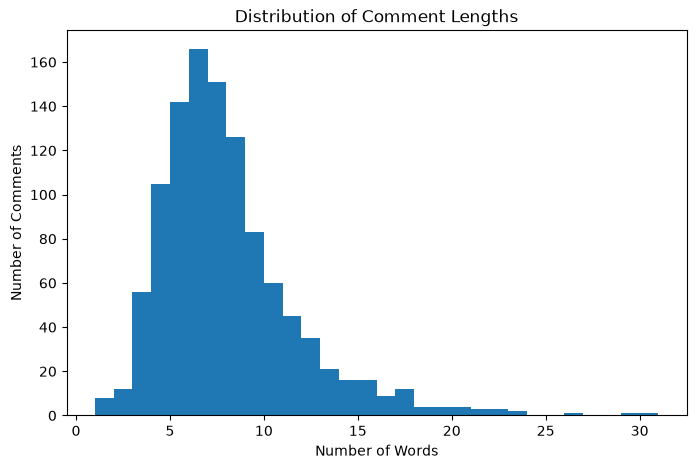

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["word_count"],
    bins=30
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comment Lengths")

plt.show()

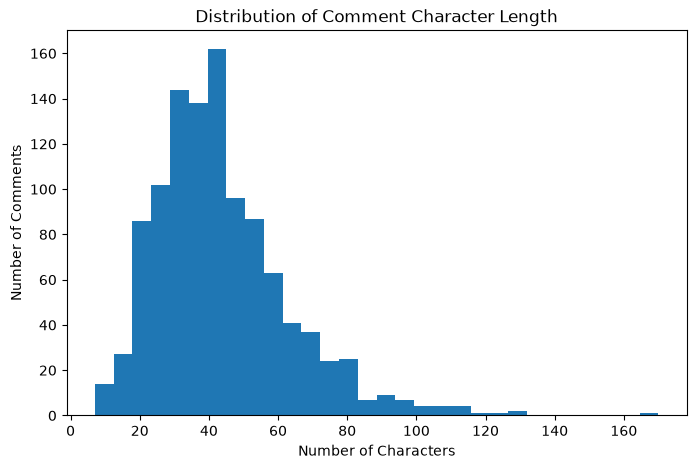

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["character_count"],
    bins=30
)

plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comment Character Length")

plt.show()

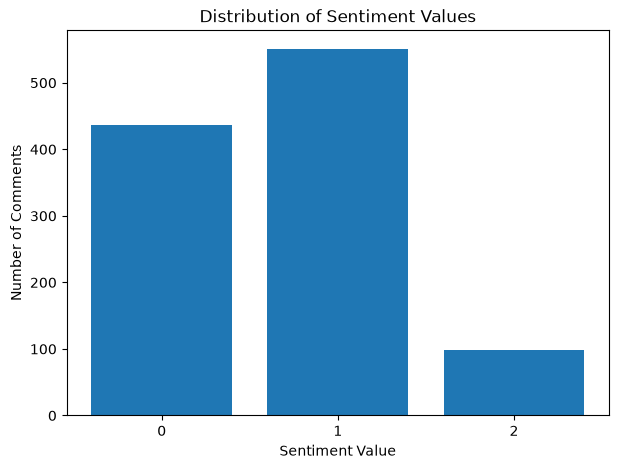

In [25]:
sentiment_counts = df["sentiments"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_counts.index.astype(str),
    sentiment_counts.values
)

plt.xlabel("Sentiment Value")
plt.ylabel("Number of Comments")
plt.title("Distribution of Sentiment Values")

plt.show()

In [26]:
empty_comments = df["comments"].str.strip().eq("").sum()

print("Empty or whitespace-only comments:", empty_comments)

Empty or whitespace-only comments: 0


In [27]:
print(df["comments"].dtype)

str


In [28]:
print("========== DATASET SUMMARY ==========")

print("Total records:", len(df))
print("Total columns:", len(df.columns))
print("Unique comments:", df["comments"].nunique())
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Average words/comment:", df["word_count"].mean())
print("Average characters/comment:", df["character_count"].mean())

========== DATASET SUMMARY ==========
Total records: 1086
Total columns: 4
Unique comments: 1063
Duplicate rows: 23
Missing values: 0
Average words/comment: 7.5755064456721914
Average characters/comment: 43.62799263351749
